<a href="https://colab.research.google.com/github/vasudevan-gomathy/stock-valuation/blob/main/Valuation_Control_Workbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Libraries

In [41]:
import pandas as pd
import numpy as np
import math
import scipy.stats as si
from datetime import datetime, date

## Reading the data

In [42]:
# Using the raw GitHub URL to directly access the Excel file content
raw_url = 'https://raw.githubusercontent.com/vasudevan-gomathy/stock_data/main/Excel%20-%20EX.xlsx'
df = pd.read_excel(raw_url)

In [43]:
df

,Underliers (Stock Names),Trade Date,Close Price ($),Unnamed: 3,Unnamed: 4,"For each of the below questions, show the working in the spreadsheet. Any assumption/s made should be explicitly stated."
0,Aaaa,2020-07-06,124.182788,NaN,NaN,NaN
1,Stock C17,2020-08-18,1214.140657,NaN,NaN,1) How many unique underliers traded as of 30t...
2,Stock C17,2021-04-30,782.225855,NaN,NaN,2) For each of the unique underliers find the ...
3,Stock C10,2020-11-13,356.305103,NaN,NaN,"3) For each of the unique underliers, find the..."
4,Stock C26,2021-01-16,775.448585,NaN,NaN,"4) For each of the unique underliers, find the..."
...,...,...,...,...,...,...
494,Stock C213,2020-10-30,2.051074,NaN,NaN,NaN
495,Stock C214,2020-09-19,2.051074,NaN,NaN,NaN
496,Stock C215,2021-03-19,2.051074,NaN,NaN,NaN
497,Stock C216,2021-04-22,2.051074,NaN,NaN,NaN


## Preprocessing and Cleaning data

In [44]:
# Removing Questions and other unnecessary columns

df.drop(df.columns[[3, 4, 5]], axis=1, inplace=True)

In [45]:
# Checking for shape(No of Rows and Columns), missing values and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Underliers (Stock Names)  499 non-null    object        
 1   Trade Date                499 non-null    datetime64[ns]
 2   Close Price ($)           499 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 11.8+ KB


In [46]:
# Stripping extra spaces in Underliers

df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [47]:
# Renaming columns to clean, python-friendly variables

df.columns = ['stock_name', 'trade_date', 'close_price']

In [48]:
# Checking for duplicate rows

duplicates = df[df.duplicated(subset=['stock_name', 'trade_date'])]
print(duplicates)

Empty DataFrame
Columns: [stock_name, trade_date, close_price]
Index: []


In [49]:
# Sorting by stock name and date

df = df.sort_values(by=['stock_name', 'trade_date'], ascending=True)

In [50]:
# Cleaned Data

df.style.hide(axis='index')

stock_name,trade_date,close_price
Aa,2020-04-19 00:00:00,244.551555
Aa,2020-07-08 00:00:00,244.727298
Aa,2020-09-26 00:00:00,174.033243
Aa,2020-12-15 00:00:00,162.434222
Aa,2021-03-05 00:00:00,175.280943
Aa,2021-04-30 00:00:00,161.689510
Aaa,2020-04-18 00:00:00,32.991752
Aaa,2020-07-07 00:00:00,34.088367
Aaa,2020-09-25 00:00:00,27.723163
Aaa,2020-12-14 00:00:00,25.681644


## Questions

### Q1) How many unique underliers traded as of 30th April according to this dataset? List them. Decribe briefly how you extracted the underliers.

In [51]:
# Assumption 1: Unique Underliers on 30th Apr 2020

# Filter specifically for April 30, 2020
df_2020 = df[df['trade_date'] == '2020-04-30']

# Extract unique list and count
underliers_2020 = df_2020['stock_name'].unique().tolist()
count_2020 = len(underliers_2020)

print("--- Data as of 30th April 2020 ---")
print(f"Count of unique underliers: {count_2020}")
print(f"List of underliers: {underliers_2020}")

--- Data as of 30th April 2020 ---
Count of unique underliers: 1
List of underliers: ['Stock C47']


In [52]:
# Assumption 2: Unique Underliers on 30th Apr 2021

# Filter specifically for April 30, 2021
df_2021 = df[df['trade_date'] == '2021-04-30']

# Extract unique list and count
underliers_2021 = df_2021['stock_name'].unique().tolist()
count_2021 = len(underliers_2021)

print("--- Data as of 30th April 2021 ---")
print(f"Count of unique underliers: {count_2021}")
print(f"List of underliers: {underliers_2021}")

--- Data as of 30th April 2021 ---
Count of unique underliers: 83
List of underliers: ['Aa', 'Aaa', 'Aaaa', 'Aaaa aaaa ccc', 'Aaaa aaaa cccc', 'Aaaa aaaa ccccc', 'Aaaa aaaa cccccc', 'Aaaa aaaa ccccccc', 'Aaaa aaaa cccccccc', 'Aaaa aaaa ccccccccc', 'Aaaa aaaa cccccccccc', 'Aaaa aaaa ccccccccccc', 'Aaaa aaaa cccccccccccc', 'Aaaa aaaa ccccccccccccc', 'Aaaa aaaa cccccccccccccc', 'Aaaa aaaa ccccccccccccccc', 'Aaaa aaaa cccccccccccccccc', 'Aaaa aaaa ccccccccccccccccc', 'Aaaa aaaa cccccccccccccccccc', 'Aaaa aaaa ccccccccccccccccccc', 'Aaaa aaaa cccccccccccccccccccc', 'Aaaaa', 'Aaaaaa', 'Aaaaaaa', 'Aaaaaaaa', 'Stock C10', 'Stock C11', 'Stock C12', 'Stock C13', 'Stock C14', 'Stock C15', 'Stock C16', 'Stock C17', 'Stock C18', 'Stock C19', 'Stock C20', 'Stock C200', 'Stock C21', 'Stock C211', 'Stock C212', 'Stock C22', 'Stock C23', 'Stock C24', 'Stock C25', 'Stock C26', 'Stock C27', 'Stock C28', 'Stock C29', 'Stock C3', 'Stock C30', 'Stock C31', 'Stock C32', 'Stock C33', 'Stock C34', 'Stock C35',

### Q2) For each of the unique underliers find the Closing Price as of 30th Apr 2021.

In [53]:
# Extract the closing prices for all unique stocks as of April 30, 2021
df_spot_prices_2021 = df[df['trade_date'] == '2021-04-30'][['stock_name', 'close_price']].reset_index(drop=True)

# Format and display the actual DataFrame with a hidden index
df_spot_prices_2021.style.hide()

stock_name,close_price
Aa,161.689510
Aaa,21.225052
Aaaa,115.279954
Aaaa aaaa ccc,651.372057
Aaaa aaaa cccc,150.647049
Aaaa aaaa ccccc,77.995674
Aaaa aaaa cccccc,337.249809
Aaaa aaaa ccccccc,333.797793
Aaaa aaaa cccccccc,285.421304
Aaaa aaaa ccccccccc,71.618659


### Q3) For each of the unique underliers, find the Average closing Price from the data set.

In [54]:
# Groupby Stock name, finding the mean and renaming close price as average close price
df_average_prices = df.groupby('stock_name', as_index=False)['close_price'].mean().rename(columns={'close_price': 'average_close_price'})

# Format and display the actual DataFrame with a hidden index
df_average_prices.style.hide()

stock_name,average_close_price
Aa,193.786128
Aaa,27.221510
Aaaa,127.605163
Aaaa aaaa ccc,848.608593
Aaaa aaaa cccc,203.113632
Aaaa aaaa ccccc,95.493227
Aaaa aaaa cccccc,445.501289
Aaaa aaaa ccccccc,405.330263
Aaaa aaaa cccccccc,335.616195
Aaaa aaaa ccccccccc,80.947184


### Q4) For each of the unique underliers, find the Minimum closing Price in the data set and the date at which it occurred.

In [55]:
# Grab the exact rows where the minimum closing price happens for each stock
df_min = df.loc[df.groupby('stock_name')['close_price'].idxmin(), ['stock_name', 'close_price', 'trade_date']]

# Rename the column to 'min close price'
df_min = df_min.rename(columns={'close_price': 'min close price'})

# Display with hidden index and formatted date
df_min.style.hide(axis='index').format({'trade_date': '{:%d/%m/%Y}'})

stock_name,min close price,trade_date
Aa,161.689510,30/04/2021
Aaa,21.225052,30/04/2021
Aaaa,115.279954,30/04/2021
Aaaa aaaa ccc,651.372057,30/04/2021
Aaaa aaaa cccc,150.647049,30/04/2021
Aaaa aaaa ccccc,77.995674,30/04/2021
Aaaa aaaa cccccc,337.249809,30/04/2021
Aaaa aaaa ccccccc,333.797793,30/04/2021
Aaaa aaaa cccccccc,285.421304,30/04/2021
Aaaa aaaa ccccccccc,71.618659,30/04/2021


### Q5) For each of the unique underliers, find the Maximum closing Price in the data set and the date at which it

In [56]:
# Grab the exact rows where the maximum closing price happens for each stock
df_max = df.loc[df.groupby('stock_name')['close_price'].idxmax(), ['stock_name', 'close_price', 'trade_date']]

# Rename the column to 'max close price'
df_max = df_max.rename(columns={'close_price': 'max close price'})

# Display with hidden index and formatted date
df_max.style.hide(axis='index').format({'trade_date': '{:%d/%m/%Y}'})

stock_name,max close price,trade_date
Aa,244.727298,08/07/2020
Aaa,34.088367,07/07/2020
Aaaa,141.324507,13/12/2020
Aaaa aaaa ccc,1250.496494,12/04/2020
Aaaa aaaa cccc,272.805450,11/04/2020
Aaaa aaaa ccccc,133.767143,29/06/2020
Aaaa aaaa cccccc,681.113043,09/04/2020
Aaaa aaaa ccccccc,569.172804,08/04/2020
Aaaa aaaa cccccccc,400.042812,26/06/2020
Aaaa aaaa ccccccccc,99.224367,25/06/2020


### Q6) Price both a Call and Put option on "Stock C4" as of 30th April 2021 Close. Strike=$50 Implied Volatility=20%. Maturity=20th Dec 2025. No Dividends are Paid.

In [57]:
# Look up the closing price for Stock C4 on April 30, 2021 using string date matching
S = df.loc[(df['stock_name'] == 'Stock C4') & (df['trade_date'] == '2021-04-30'), 'close_price'].values[0]

# Calculate the time to maturity in years by dividing the total days by 365
start_date = datetime(2021, 4, 30)
maturity_date = datetime(2025, 12, 20)
T = (maturity_date - start_date).days / 365.0

# Define remaining inputs
K = 50.00
vol = 0.20
r = 0.0085  # Assuming a risk-free rate of 0.85%, based on the 5-year US Treasury bond as of April 30, 2021

# Calculate d1 and d2
d1 = (math.log(S / K) + (r + (vol ** 2) / 2) * T) / (vol * math.sqrt(T))
d2 = d1 - vol * math.sqrt(T)

# Calculate Call and Put prices
call_price = S * si.norm.cdf(d1) - K * math.exp(-r * T) * si.norm.cdf(d2)
put_price = K * math.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)

# Final Display
print(f"Spot Price used: ${round(S, 2)}\n")
print(f"Call Option Price: ${call_price:.2f}")
print(f"Put Option Price:  ${put_price:.2f}")

Spot Price used: $41.1

Call Option Price: $4.61
Put Option Price:  $11.58


### Q7) Price a Forward on "Stock C3" expiring in 3 Months. Dividend=1%, Risk Free Rate = 3%

In [58]:
# Define model inputs
r = 0.03    # 3% Risk-free rate
q = 0.01    # 1% Dividend yield
T = 0.25    # 3 Months to maturity (3/12 of a year)

# Filter for Stock C3 on or before April 30, 2021
target_date = "2021-04-30"
stock_data = df[(df['stock_name'] == 'Stock C3') & (df['trade_date'] <= target_date)]

# Get the most recent closing price
S = float(stock_data.sort_values('trade_date')['close_price'].iloc[-1])

# Calculate forward price using continuous compounding
f_continuous = S * math.exp((r - q) * T)

# Calculate forward price using discrete compounding
f_discrete = S * ((1 + r)**T) / ((1 + q)**T)

# Display final results
print(f"Spot Price used: ${S:.2f}\n")
print(f"Continuous Compounding Forward Price: ${f_continuous:.2f}")
print(f"Discrete Compounding Forward Price:   ${f_discrete:.2f}")

Spot Price used: $177.42

Continuous Compounding Forward Price: $178.31
Discrete Compounding Forward Price:   $178.29


## Extras - Valuation Trend Analysis: Top 5 Underliers



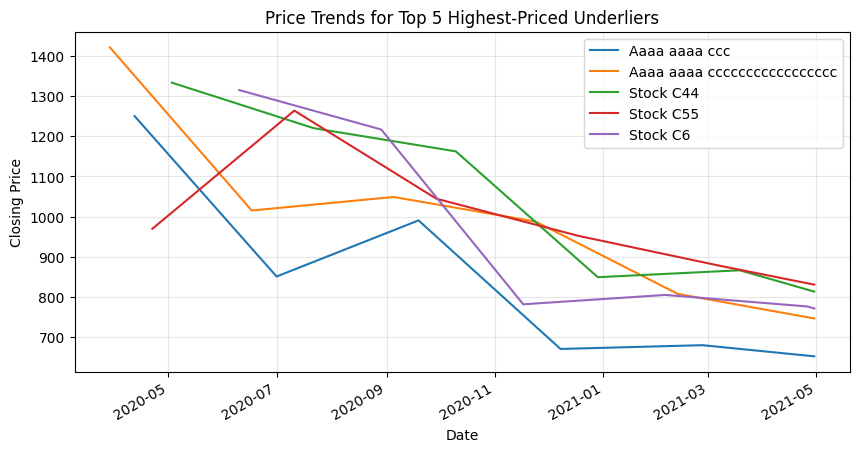

In [59]:
import matplotlib.pyplot as plt

# Find the 5 stocks with the highest maximum closing prices
top_5_stocks = df.groupby('stock_name')['close_price'].max().nlargest(5).index

# Filter your main data to keep only those 5 stocks
df_filtered = df[df['stock_name'].isin(top_5_stocks)]

# Plot the clean trend lines
df_filtered.set_index('trade_date').groupby('stock_name')['close_price'].plot(legend=True, figsize=(10, 5))

# Labels
plt.title('Price Trends for Top 5 Highest-Priced Underliers')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, alpha=0.3)

plt.show()